In [5]:
import pandas as pd
import json
import os
from datetime import datetime

# Load datasets safely
try:
    fg_df = pd.read_csv('fear_greed_index.csv')
    hist_df = pd.read_csv('historical_data.csv')
    print("Files successfully loaded.")
except Exception as e:
    print(f"Error loading files: {e}")

Files successfully loaded.


In [6]:
def run_sentiment_analysis_pipeline():
    """
    Cleans raw blockchain trading data, pairs it with market sentiment index,
    and returns a structured JSON summary evaluating trader performance.
    """
    # 1. Standardize and parse dates (Data Engineering)
    fg_df['date_clean'] = pd.to_datetime(fg_df['date']).dt.date
    hist_df['date_clean'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date

    # Drop records with malformed dates
    hist_df.dropna(subset=['date_clean'], inplace=True)

    # 2. Merge datasets
    merged_df = pd.merge(hist_df, fg_df[['date_clean', 'value', 'classification']], on='date_clean', how='inner')

    # Helper classifications
    merged_df['is_win'] = merged_df['Closed PnL'] > 0
    merged_df['is_loss'] = merged_df['Closed PnL'] < 0

    # 3. Aggregate Performance Analytics
    sentiment_groups = merged_df.groupby('classification')

    metrics_output = {
        "metadata": {
            "pipeline_run_timestamp": datetime.now().isoformat(),
            "total_records_analyzed": len(merged_df),
            "status": "SUCCESS"
        },
        "metrics_by_regime": {}
    }

    for name, group in sentiment_groups:
        total = int(group['Closed PnL'].count())
        wins = int(group['is_win'].sum())
        losses = int(group['is_loss'].sum())

        metrics_output["metrics_by_regime"][name] = {
            "total_trades": total,
            "win_rate": round(wins / (wins + losses), 4) if (wins + losses) > 0 else 0.0,
            "avg_pnl_usd": round(float(group['Closed PnL'].mean()), 2),
            "avg_position_size_usd": round(float(group['Size USD'].mean()), 2)
        }

    # 4. Enforce strict JSON output serialization
    strict_json_output = json.dumps(metrics_output, indent=4)
    return strict_json_output

# Run the pipeline and print the output
json_result = run_sentiment_analysis_pipeline()
print(json_result)

# Save the JSON string to a file for submission deployment
with open('pipeline_evaluation_output.json', 'w') as f:
    f.write(json_result)

{
    "metadata": {
        "pipeline_run_timestamp": "2026-07-17T04:25:26.679524",
        "total_records_analyzed": 211218,
        "status": "SUCCESS"
    },
    "metrics_by_regime": {
        "Extreme Fear": {
            "total_trades": 21400,
            "win_rate": 0.7622,
            "avg_pnl_usd": 34.54,
            "avg_position_size_usd": 5349.73
        },
        "Extreme Greed": {
            "total_trades": 39992,
            "win_rate": 0.8917,
            "avg_pnl_usd": 67.89,
            "avg_position_size_usd": 3112.25
        },
        "Fear": {
            "total_trades": 61837,
            "win_rate": 0.8729,
            "avg_pnl_usd": 54.29,
            "avg_position_size_usd": 7816.11
        },
        "Greed": {
            "total_trades": 50303,
            "win_rate": 0.7689,
            "avg_pnl_usd": 42.74,
            "avg_position_size_usd": 5736.88
        },
        "Neutral": {
            "total_trades": 37686,
            "win_rate": 0.8239,
      

/tmp/ipykernel_622/2073151035.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='Closed PnL', ci=None, palette='coolwarm')
/tmp/ipykernel_622/2073151035.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='Closed PnL', ci=None, palette='coolwarm')


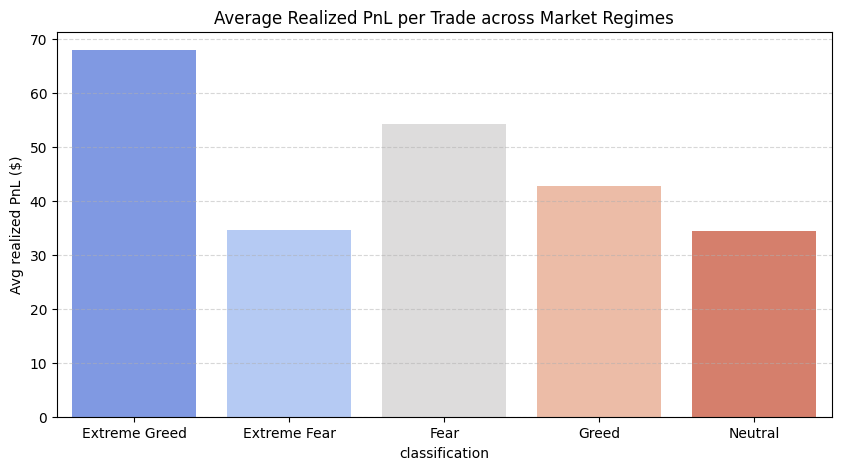

/tmp/ipykernel_622/2073151035.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='classification', y='Size USD', showfliers=False, palette='viridis')


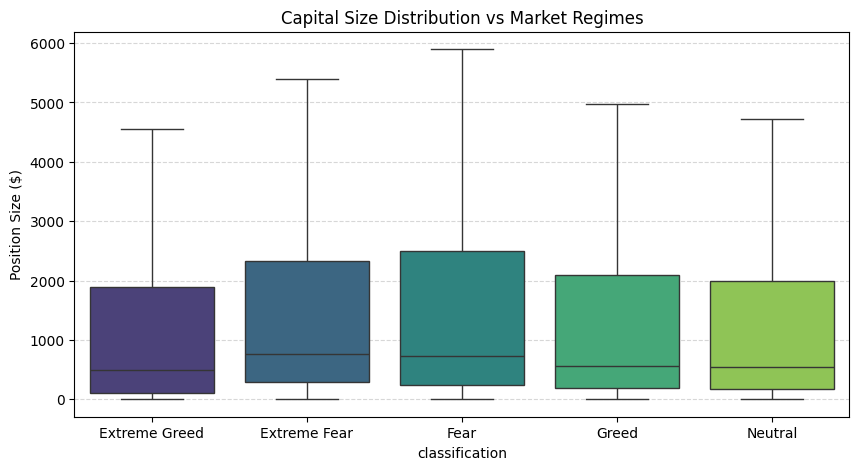

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Convert dates for plotting
fg_df['date_clean'] = pd.to_datetime(fg_df['date']).dt.date
hist_df['date_clean'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date
merged_df = pd.merge(hist_df, fg_df[['date_clean', 'classification']], on='date_clean', how='inner')

# Chart 1: Average realized performance per emotional phase
plt.figure(figsize=(10, 5))
sns.barplot(data=merged_df, x='classification', y='Closed PnL', ci=None, palette='coolwarm')
plt.title('Average Realized PnL per Trade across Market Regimes')
plt.ylabel('Avg realized PnL ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('sentiment_vs_pnl.png', dpi=300)
plt.show()

# Chart 2: Capital risk concentration
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged_df, x='classification', y='Size USD', showfliers=False, palette='viridis')
plt.title('Capital Size Distribution vs Market Regimes')
plt.ylabel('Position Size ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('sentiment_vs_size.png', dpi=300)
plt.show()